In [1]:
# Importo las librerías que voy a necesitar
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Bokeh: la uso para hacer gráficas interactivas
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import ColumnDataSource
from bokeh.transform import factor_cmap
from bokeh.palettes import Category10

# Esto hace que las gráficas de Bokeh aparezcan dentro del notebook
output_notebook()
df=pd.read_csv("Telefonía_Móvil_abonados_por_categoría_20260518.csv",)
print(df.head())

Loading BokehJS ...

    AÑO  TRIMESTRE                                         PROVEEDOR  \
0  2022          1           COLOMBIA TELECOMUNICACIONES S.A. E.S.P.   
1  2022          3                                 SUMA MOVIL S.A.S.   
2  2021          3  EMPRESA DE TELECOMUNICACIONES DE BOGOTA S.A. ESP   
3  2023          3               COMUNICACION CELULAR S A COMCEL S A   
4  2023          2                           COLOMBIA MOVIL  S.A ESP   

   LINEAS EN SERVICIO  LINEAS PREPAGO  LINEAS POSPAGO  LÍNEAS ACTIVADAS  \
0            18866239       5107397.0         2023775           1934632   
1               26528             0.0            8037              6668   
2              262112        154340.0           39865             72194   
3            38701128      10134039.0         4756796           4918874   
4            15167954       3589610.0         3882993           3783549   

   LÍNEAS RETIRADAS  
0          13758842  
1             26528  
2            107772  
3          28567089  
4     

In [22]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
import pandas as pd

output_notebook()

# limpiar nombres de columnas
df.columns = df.columns.str.strip()

# convertir a numérico
df['LINEAS EN SERVICIO'] = pd.to_numeric(
    df['LINEAS EN SERVICIO'],
    errors='coerce'
)
# agrupar por año y sumar líneas
datos = df.groupby('AÑO')['LINEAS EN SERVICIO'].sum()

# crear figura
p = figure(
    x_range=x,
    height=400,
    width=800,
    title="Líneas en servicio por año",
    toolbar_location=None,
    tools=""
)

# barras
p.vbar(
    x=x,
    top=y,
    width=0.7,
    color="khaki",
    line_color="skyblue"    # borde blanco entre barras
)

# Le pongo etiquetas a los ejes
p.xaxis.axis_label = "Año"
p.yaxis.axis_label = "Número de Líneas en Servicio"
# Elimino las líneas verticales del fondo (queda más limpio)
p.xgrid.grid_line_color = None

# El eje Y empieza en 0 (por defecto a veces empieza en otro número)
p.y_range.start = 0

# Estilo del título
p.title.text_font_size = "18pt"

# Muestro la gráfica
show(p)

Loading BokehJS ...

In [78]:
# ---- PREPARACIÓN DE LOS DATOS ----

# Agrupo por año y sumo tanto las líneas prepago como las pospago
# Puedo agrupar varias columnas a la vez poniéndolas en una lista
datos_tipo = df.groupby('AÑO')[['LINEAS PREPAGO', 'LINEAS POSPAGO']].sum()
print("Líneas prepago y pospago por año:")
print(datos_tipo)
print()

años = list(datos_tipo.index)                         # lista de años: [2015, 2016, ...]
prepago = list(datos_tipo['LINEAS PREPAGO'])   # lista de totales prepago
pospago = list(datos_tipo['LINEAS POSPAGO'])   # lista de totales pospago

print("Años:", años)

Líneas prepago y pospago por año:
      LINEAS PREPAGO  LINEAS POSPAGO
AÑO                                 
2015      11448739.0         9375234
2016      47247895.0        34296267
2017      49700006.0        36752813
2018      52196756.0        39476713
2019      54992370.0        40135703
2020      56900981.0        38051941
2021      65013313.0        49116070
2022      76406575.0        50316245
2023      62901431.0        36294699

Años: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


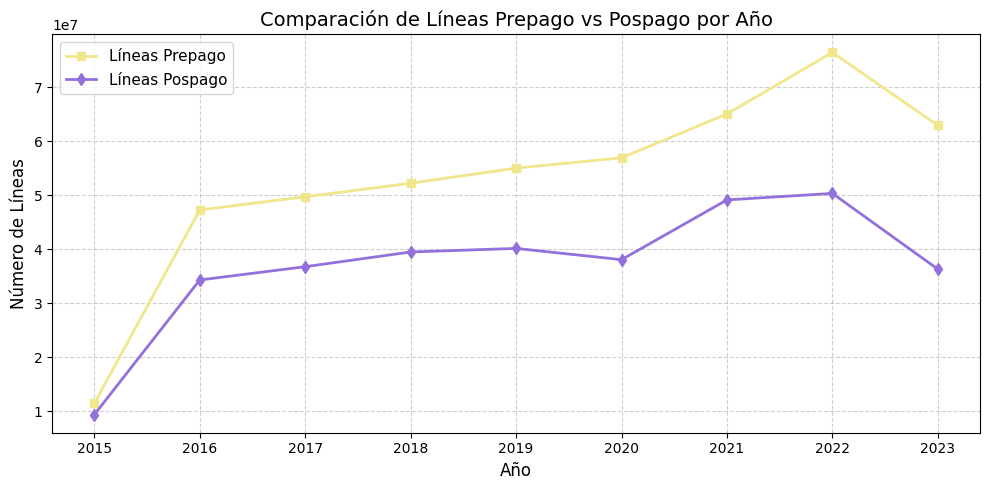

In [ ]:
# figsize=(10, 5) es el tamaño en pulgadas (ancho, alto)
plt.figure(figsize=(10, 5))

# marker='s' pone un cuadro en cada punto  y d un diamante 
# linewidth es el grosor de la línea
plt.plot(años, prepago, marker='s', color='khaki', label='Líneas Prepago', linewidth=2)

# Dibujo la línea de pospago encima de la misma gráfica
plt.plot(años, pospago, marker='d', color='mediumpurple', label='Líneas Pospago', linewidth=2)


# Agrego el título de la gráfica
plt.title('Comparación de Líneas Prepago vs Pospago por Año', fontsize=14)

# Etiquetas de los ejes
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de Líneas', fontsize=12)

# La leyenda explica qué representa cada línea
plt.legend(fontsize=11)

# Agrego líneas de fondo (grilla) para facilitar la lectura
plt.grid(True, linestyle='--', alpha=0.6)

# tight_layout ajusta automáticamente los márgenes para que todo quepa bien
plt.tight_layout()

# Muestro la gráfica
plt.show()

In [ ]:

# Agrupo por proveedor y sumo todas sus líneas en servicio (de todos los años)
lineas_por_proveedor = df.groupby('PROVEEDOR')['LINEAS EN SERVICIO'].sum()

# Ordeno de mayor a menor y me quedo solo con los 5 primeros
# sort_values() ordena los valores
# ascending=False significa de mayor a menor 
# head(5) toma solo los primeros 5
top5 = lineas_por_proveedor.sort_values(ascending=False).head(5)

print("Top 5 proveedores con más líneas en servicio:")
print(top5)

# Guardo los nombres y los valores en listas
nombres = list(top5.index) # nombres de los proveedores
valores = list(top5.values)   # cantidad de líneas de cada uno

# Para que las barras queden ordenadas de arriba hacia abajo (mayor arriba),
# invierto las listas con [::-1]
nombres = nombres[::-1]
valores = valores[::-1]

print("Proveedores ordenados para la gráfica:", nombres)

Top 5 proveedores con más líneas en servicio:
PROVEEDOR
COMUNICACION CELULAR S A COMCEL S A        1025204439
COLOMBIA TELECOMUNICACIONES S.A. E.S.P.     523666396
COLOMBIA MOVIL  S.A ESP                     397048796
VIRGIN MOBILE COLOMBIA S.A.S.                87392078
ALMACENES EXITO INVERSIONES S.A.S.           43464145
Name: LINEAS EN SERVICIO, dtype: int64
Proveedores ordenados para la gráfica: ['ALMACENES EXITO INVERSIONES S.A.S.', 'VIRGIN MOBILE COLOMBIA S.A.S.', 'COLOMBIA MOVIL  S.A ESP', 'COLOMBIA TELECOMUNICACIONES S.A. E.S.P.', 'COMUNICACION CELULAR S A COMCEL S A']


In [100]:
# Los nombres de los proveedores son muy largos, así que los acorto
# Creo un diccionario donde la clave es el nombre original y el valor es el nombre corto
nombres_cortos = {
    'COMUNICACION CELULAR S A COMCEL S A' : 'Claro',
    'COLOMBIA TELECOMUNICACIONES S.A. E.S.P.' : 'Movistar',
    'COLOMBIA MOVIL  S.A ESP'            : 'Tigo',
    'VIRGIN MOBILE COLOMBIA S.A.S.'      : 'Virgin Mobile',
    
}
# Si el nombre no está en el diccionario, lo dejo como está (eso hace el .get())
nombres_c = [nombres_cortos.get(n, n) for n in nombres]

print("Nombres cortos para mostrar en la gráfica:")
for n in nombres_c:
    print(" -", n)

Nombres cortos para mostrar en la gráfica:
 - ALMACENES EXITO INVERSIONES S.A.S.
 - Virgin Mobile
 - Tigo
 - Movistar
 - Claro


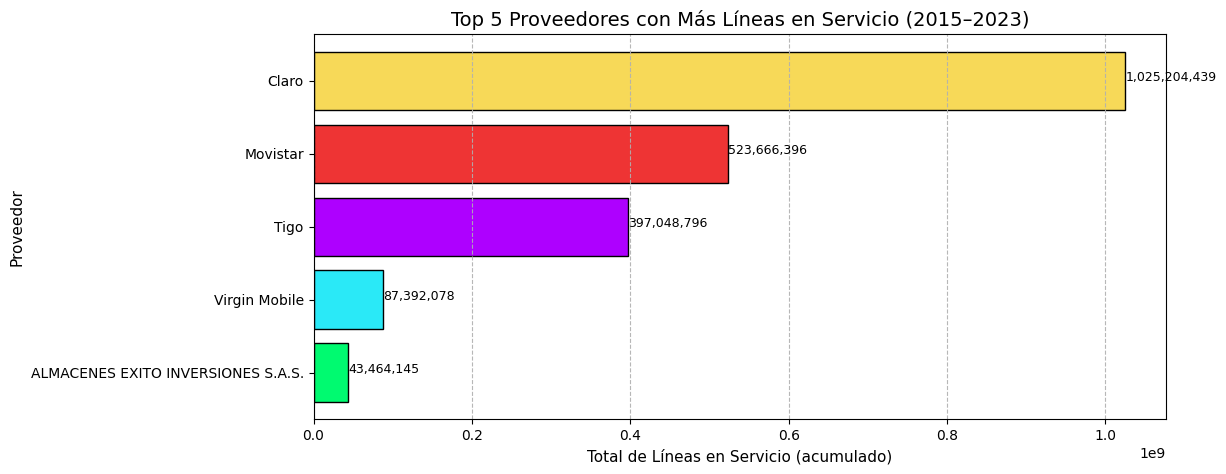

In [144]:

# Defino colores diferentes para cada barra
colores = ["#00FA70", "#2AE9F7", "#AE00FF", "#EE3434", "#F7D958"]

# Creo la figura con tamaño horizontal (ancho - alto) para que los nombres quepan
plt.figure(figsize=(11, 5))

barras = plt.barh(
    nombres_c,   # categorías en el eje Y
    valores,           # valores en el eje X
    color=colores,
    edgecolor='black'
)

# Agrego el valor al final de cada barra para que se vea exactamente cuánto es
#  Esto se hace con plt.text() que escribe texto en coordenadas específicas
#enumerate() en Python sirve para recorrer elementos de una colección  mientras genera un contador automático
#zip() sirve para combinar elementos en pares ordenados,tomalos elementos en la misma posición y los agrupa en tuplas
for i, (barra, valor) in enumerate(zip(barras, valores)):
    # barra.get_width() me da el ancho de la barra (el valor numérico)
    # barra.get_y() + barra.get_height()/2 me da la posición vertical del centro
    # El ':,.0f' formatea el número con comas para separar miles
    plt.text(
        barra.get_width() * 1,            # posición X (un poco a la derecha de la barra)
        barra.get_y() + barra.get_height()/2, # posición Y (centro de la barra)
        f'{valor:,.0f}',                      # texto con formato de miles
        fontsize=9
    )
plt.title('Top 5 Proveedores con Más Líneas en Servicio (2015–2023)', fontsize=14)
plt.xlabel('Total de Líneas en Servicio (acumulado)', fontsize=11)
plt.ylabel('Proveedor', fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.9)

plt.show()